In [ ]:
import kagglehub
import os
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("tanjemahamed/odir5k-classification")

print("Path to dataset files:", path)

dataset_dir = path

100%|██████████| 374M/374M [00:03<00:00, 130MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/tanjemahamed/odir5k-classification/versions/1


In [ ]:
print(f"\nContents of {dataset_dir}:")
for root, dirs, files in os.walk(dataset_dir):
    for file in files:
        print(os.path.join(root, file))
    for dir in dirs:
        print(os.path.join(root, dir))


Contents of /root/.cache/kagglehub/datasets/tanjemahamed/odir5k-classification/versions/1:
/root/.cache/kagglehub/datasets/tanjemahamed/odir5k-classification/versions/1/datasets
/root/.cache/kagglehub/datasets/tanjemahamed/odir5k-classification/versions/1/datasets/glaucoma
/root/.cache/kagglehub/datasets/tanjemahamed/odir5k-classification/versions/1/datasets/normal
/root/.cache/kagglehub/datasets/tanjemahamed/odir5k-classification/versions/1/datasets/others
/root/.cache/kagglehub/datasets/tanjemahamed/odir5k-classification/versions/1/datasets/cataract
/root/.cache/kagglehub/datasets/tanjemahamed/odir5k-classification/versions/1/datasets/diabetes
/root/.cache/kagglehub/datasets/tanjemahamed/odir5k-classification/versions/1/datasets/ageDegeneration
/root/.cache/kagglehub/datasets/tanjemahamed/odir5k-classification/versions/1/datasets/myopia
/root/.cache/kagglehub/datasets/tanjemahamed/odir5k-classification/versions/1/datasets/hypertension
/root/.cache/kagglehub/datasets/tanjemahamed/odi

(12784, 2)
normal


100%|██████████| 5/5 [00:00<00:00, 74.48it/s]


cataract


100%|██████████| 5/5 [00:00<00:00, 425.38it/s]


glaucoma


...

100%|██████████| 5/5 [00:00<00:00, 185.23it/s]


others


100%|██████████| 5/5 [00:00<00:00, 264.94it/s]


agedegeneration


100%|██████████| 5/5 [00:00<00:00, 405.96it/s]


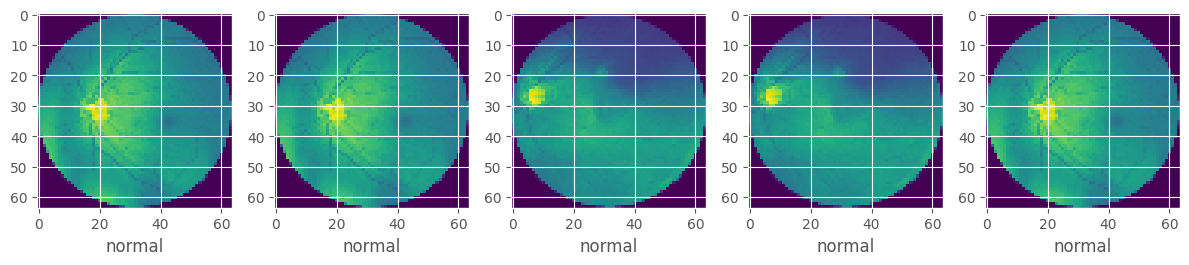

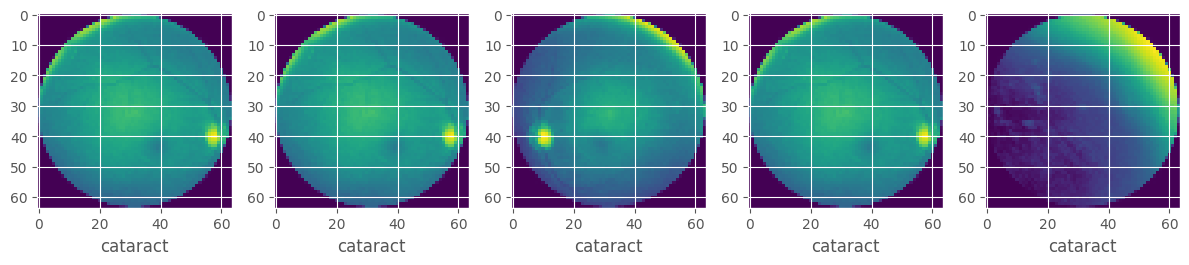

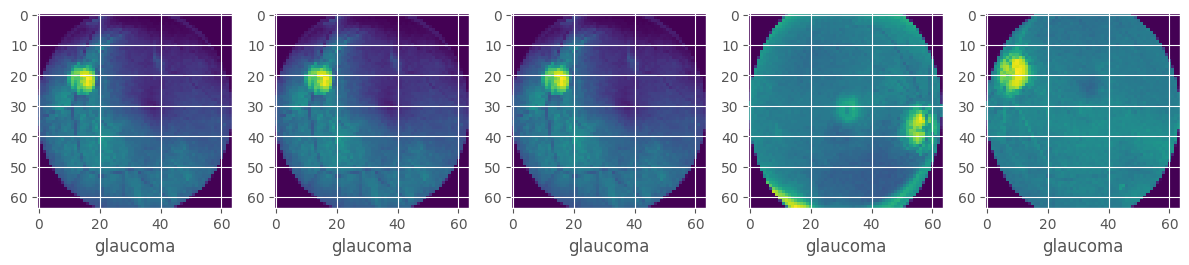

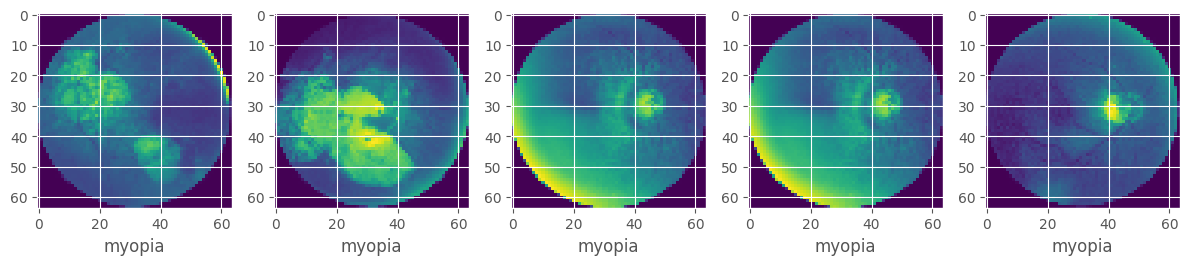

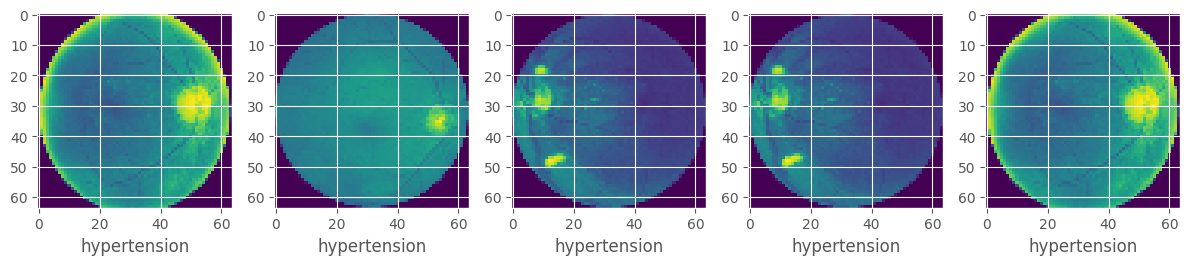

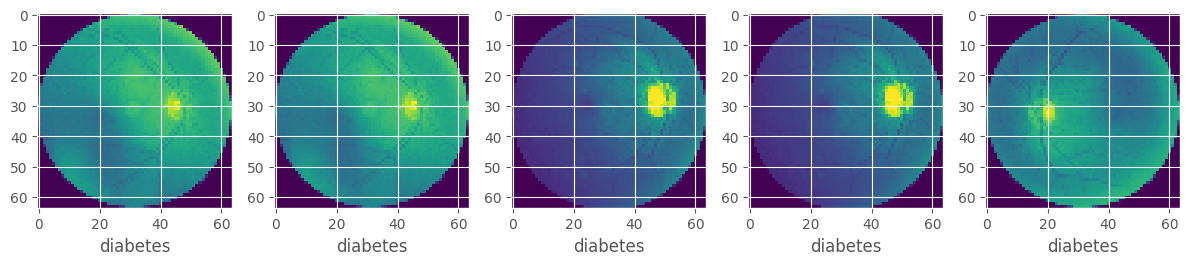

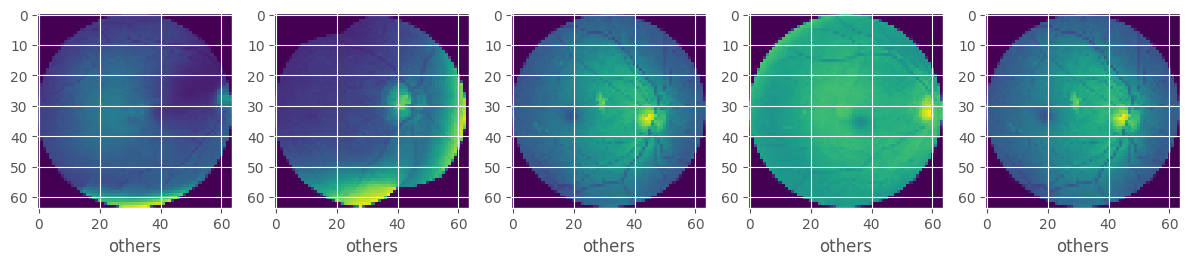

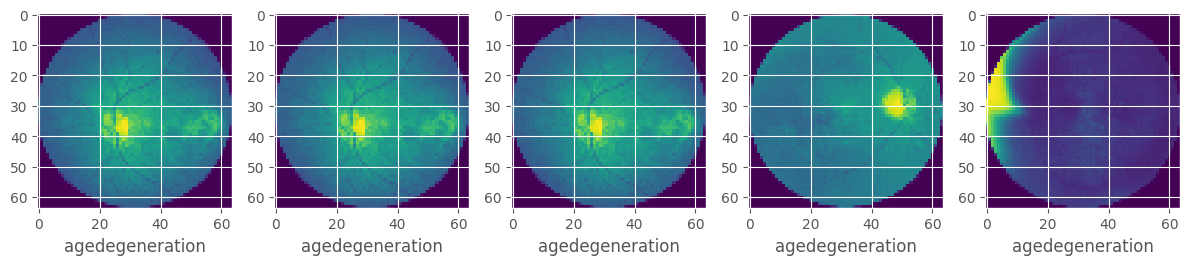

In [ ]:
from pathlib import Path

image_dir = Path(dataset_dir)

# Get filepaths and labels
filepaths = list(image_dir.glob(r'**/*.JPG')) + list(image_dir.glob(r'**/*.jpeg')) + list(image_dir.glob(r'**/*.jpg')) + list(image_dir.glob(r'**/*.png')) + list(image_dir.glob(r'**/*.png'))

labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))

filepaths = pd.Series(filepaths, name='Filepath').astype(str)
labels = pd.Series(labels, name='Label')

# Concatenate filepaths and labels
image_df = pd.concat([filepaths, labels], axis=1)
print (image_df.shape)

image_size=224

def convert_image_to_array_grayscale(image_dir):
    try:
        image = cv2.imread(image_dir)
        if image is not None :
            grayimg = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
            grayimg = cv2.resize(grayimg, (64, 64))
            return grayimg
        else :
            return np.array([])
    except Exception as e:
        print(f"Error : {e}")
        return None

def create_dataset(image_category,label):
    current_dataset = [] # Use a local dataset for this function call
    for img_filepath in tqdm(image_category):
        # Use the existing convert_image_to_array_grayscale function
        processed_image = convert_image_to_array_grayscale(img_filepath)
        if processed_image is not None and processed_image.size > 0:
            current_dataset.append([np.array(processed_image),np.array(label)])
    return current_dataset
categories = [x.lower() for x in list(set(image_df['Label'].values))]

for label in categories:
    print (label)
    # Filter image_df using lowercase labels for consistent comparison
    req_images = image_df[image_df['Label'].str.lower() == label]['Filepath'].values

    # Ensure there are enough images to slice before creating dataset
    if len(req_images) >= 15:
        dataset = create_dataset(req_images[10:15],1)
    elif len(req_images) > 0:
        dataset = create_dataset(req_images[:min(len(req_images), 5)], 1) # Take up to 5 images if available
    else:
        dataset = [] # No images to process

    if len(dataset) > 0:
        plt.figure(figsize=(12,7))
        for i in range(5):
            sample = random.choice(range(len(dataset)))
            image = dataset[sample][0]
            category = dataset[sample][1]
            plt.subplot(1,5,i+1)
            plt.imshow(image)
            plt.xlabel(label)
        plt.tight_layout()
    else:
        print(f"No images to display for label: {label}")

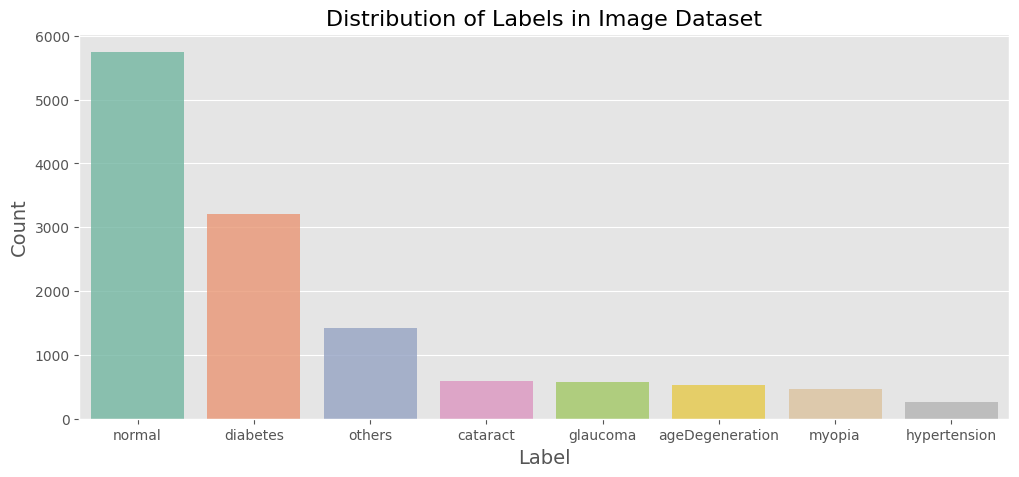

In [ ]:
label_counts = image_df['Label'].value_counts()

plt.figure(figsize=(12, 5))
sns.barplot(x=label_counts.index, y=label_counts.values, alpha=0.8, palette='Set2')
plt.title('Distribution of Labels in Image Dataset', fontsize=16)
plt.xlabel('Label', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=0)
plt.show()

In [ ]:
from collections import Counter
from tabulate import tabulate
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import os

# Use the already processed image_df from previous steps
image_paths = image_df['Filepath'].values
labels = image_df['Label'].values

# =====================================
# 1. DATASET DESCRIPTION
# =====================================
total_images = len(image_paths)
num_classes = len(set(labels))
class_counts = Counter(labels)

# Pretty Class Distribution Table
class_table = [[cls, count] for cls, count in class_counts.items()]

print("\n📊 Class Distribution:\n")
print(tabulate(class_table, headers=["Class", "Count"], tablefmt="fancy_grid"))

# =====================================
# 2. TRAIN-TEST SPLIT
# =====================================
X_train, X_test, y_train, y_test = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

# =====================================
# 3. SUMMARY TABLE
# =====================================
summary_data = [
    ["Total Images", total_images],
    ["Number of Classes", num_classes],
    ["Training Samples", len(X_train)],
    ["Testing Samples", len(X_test)]
]

print("\n📌 Dataset Summary:\n")
print(tabulate(summary_data, headers=["Metric", "Value"], tablefmt="fancy_grid"))


📊 Class Distribution:

╒═════════════════╤═════════╕
│ Class           │   Count │
╞═════════════════╪═════════╡
│ glaucoma        │     568 │
├─────────────────┼─────────┤
│ normal          │    5746 │
├─────────────────┼─────────┤
│ others          │    1416 │
├─────────────────┼─────────┤
│ cataract        │     586 │
├─────────────────┼─────────┤
│ diabetes        │    3216 │
├─────────────────┼─────────┤
│ ageDegeneration │     532 │
├─────────────────┼─────────┤
│ myopia          │     464 │
├─────────────────┼─────────┤
│ hypertension    │     256 │
╘═════════════════╧═════════╛

📌 Dataset Summary:

╒═══════════════════╤═════════╕
│ Metric            │   Value │
╞═══════════════════╪═════════╡
│ Total Images      │   12784 │
├───────────────────┼─────────┤
│ Number of Classes │       8 │
├───────────────────┼─────────┤
│ Training Samples  │   10227 │
├───────────────────┼─────────┤
│ Testing Samples   │    2557 │
╘═══════════════════╧═════════╛


In [ ]:
import cv2
import numpy as np

IMG_SIZE = 224

def preprocess_image(img):

    # 1. Resize
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # 2. Noise Removal (Gaussian Blur)
    img = cv2.GaussianBlur(img, (5, 5), 0)

    # 3. Rescaling (Normalization)
    img = img / 255.0

    return img

In [ ]:
finalList  = []
finalLabelList = []
len_dataset = len(dataset)
print (len_dataset)
for x in range(0,len_dataset):
    if(len(dataset[x]) > 0):
        # Access the NumPy array (first element) and reshape it
        reqArr = dataset[x][0].reshape(1,4096)
        finalList.append(reqArr)
        finalLabelList.append(labels[x])

print ("Final List is Generated ..... ")
dfLabelList = []
for x in range(0,4095):
    label = 'pixel'+str(x)
    dfLabelList.append(label)
dfLabelList.append('Target')

print ("LabelList is created ......")

final_data = [y[0] for y in finalList]
df = pd.DataFrame(final_data)
df[4096] = finalLabelList

# Get all unique labels from the image_df DataFrame
all_unique_labels = image_df['Label'].unique()

# Create a dynamic mapping from label string to integer
# This ensures all present labels are mapped
nodeStatus = {label: i for i, label in enumerate(all_unique_labels)}

# Create a list of class names ordered by their integer mapping for consistent use
class_names_full = [label for label, _ in sorted(nodeStatus.items(), key=lambda item: item[1])]

# Apply the dynamic mapping to the 'Target' column (which is df[4096])
df[4096] = [nodeStatus[label_str] for label_str in df[4096]]
df.head()

5
Final List is Generated ..... 
LabelList is created ......


,0,1,2,3,4,5,6,7,8,9,...,4087,4088,4089,4090,4091,4092,4093,4094,4095,4096
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

def process_image_data(image_paths, labels, label_map):
    processed_images = []
    processed_labels = []
    # Ensure 4096 pixels (64x64) as expected by previous cells
    expected_flat_size = 64 * 64

    for i, img_filepath in tqdm(enumerate(image_paths), total=len(image_paths), desc="Processing Images"):
        processed_img = convert_image_to_array_grayscale(img_filepath)
        if processed_img is not None and processed_img.size == expected_flat_size:
            processed_images.append(processed_img.flatten())
            # Access the label by positional index using standard NumPy indexing
            processed_labels.append(label_map[labels[i]])
        # else: Image processing failed or size mismatch, it will be skipped.
    return np.array(processed_images), np.array(processed_labels)

# Restore X_train, X_test, y_train, y_test to their string-label versions
# as they were defined in cell MZLQAgm1XshQ, before being overwritten by EvJoAOxuZxkc.
# This assumes image_paths and labels are still correctly defined from MZLQAgm1XshQ.
X_train_corrected, X_test_corrected, y_train_corrected, y_test_corrected = train_test_split(
    image_paths, # These are filepaths (strings)
    labels,      # These are string labels
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print("Processing training images...")
X_train_processed, y_train_processed = process_image_data(X_train_corrected, y_train_corrected, nodeStatus)

print("Processing testing images...")
X_test_processed, y_test_processed = process_image_data(X_test_corrected, y_test_corrected, nodeStatus)

# Convert processed data into DataFrames
df_train = pd.DataFrame(X_train_processed)
df_train['Target'] = y_train_processed

df_test = pd.DataFrame(X_test_processed)
df_test['Target'] = y_test_processed

print(f"\nShape of processed training data: {df_train.shape}")
print(f"Shape of processed testing data: {df_test.shape}")

# Verify the counts again using the new DataFrames
x = PrettyTable(padding_width=5)
x.field_names = [" Description ", "Counter"]
x.add_row(['Total number of records (processed)', str(len(df_train) + len(df_test))])
x.add_row(['Number of records in training set (processed)', str(len(df_train))])
x.add_row(['Number of records in testing set (processed)', str(len(df_test))])
print (x)

Processing training images...


Processing Images: 100%|██████████| 10227/10227 [00:20<00:00, 501.21it/s]


Processing testing images...


Processing Images: 100%|██████████| 2557/2557 [00:03<00:00, 672.39it/s]


Shape of processed training data: (10227, 4097)
Shape of processed testing data: (2557, 4097)
+-------------------------------------------------------+-----------------+
|                      Description                      |     Counter     |
+-------------------------------------------------------+-----------------+
|          Total number of records (processed)          |      12784      |
|     Number of records in training set (processed)     |      10227      |
|      Number of records in testing set (processed)     |       2557      |
+-------------------------------------------------------+-----------------+


In [ ]:
pca = decomposition.PCA(n_components = 0.95)
pca.fit(X_train_processed)
X_train_pca = pca.transform(X_train_processed)
X_test_pca = pca.transform(X_test_processed)

catboost_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    loss_function='MultiClass',
    verbose=200,  # Print progress every 200 iterations
    random_state=42
)

# Fit the model
catboost_model.fit(X_train_pca, y_train_processed)

# 6. Make predictions
y_pred = catboost_model.predict(X_test_pca)

0:	learn: 1.9551406	total: 120ms	remaining: 2m
200:	learn: 0.8905764	total: 10.8s	remaining: 43s
400:	learn: 0.5747667	total: 21.6s	remaining: 32.3s
600:	learn: 0.3874658	total: 32.4s	remaining: 21.5s
800:	learn: 0.2772196	total: 42.7s	remaining: 10.6s
999:	learn: 0.2071251	total: 53s	remaining: 0us



Actual vs Predicted Values (First 5 records with Images):


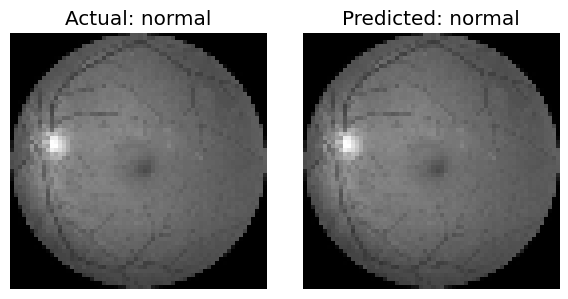

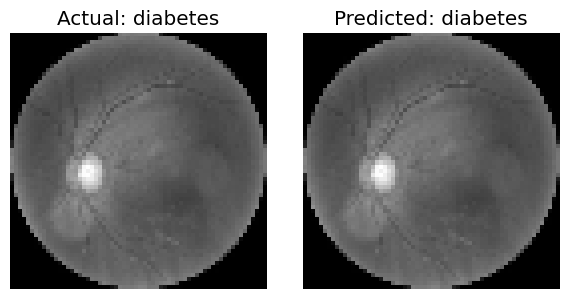

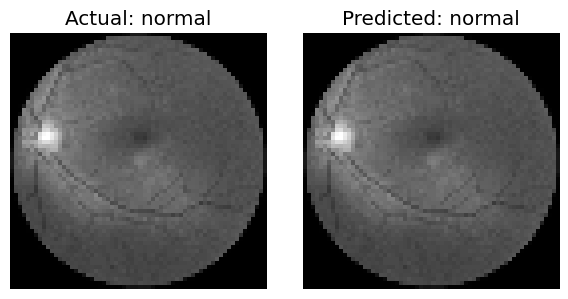

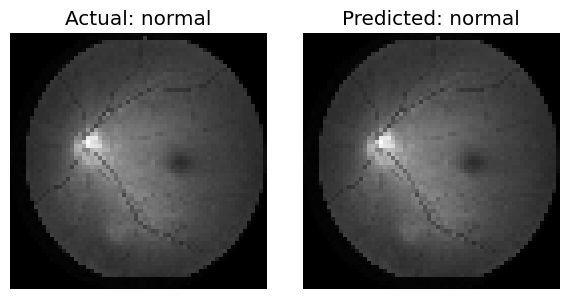

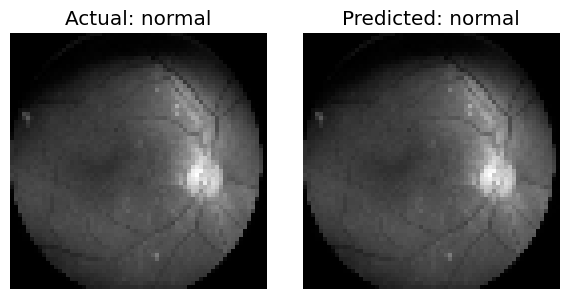

In [ ]:
from IPython.display import display, Image as IPImage
import matplotlib.pyplot as plt
from io import BytesIO

def print_predictions_images(y_pred, X_test, y_test, X_train, class_names=None):
    """
    Print actual vs predicted values with images, limited to 5 records
    Parameters:
        model: trained RandomForestClassifier
        X_test: test features
        y_test: actual labels
        image_data: list/array of image paths or numpy arrays
        class_names: list of class names (optional)
    """

    # If class names are not provided, use numerical labels
    if class_names is None:
        class_names = [str(i) for i in range(len(np.unique(y_test)))]

    # Create a DataFrame for results
    results_df = pd.DataFrame({
        'Sample Index': range(len(y_test)),
        'Actual': [class_names[label] for label in y_test],
        'Predicted': [class_names[label[0]] for label in y_pred],
        'Correct': [y_test[i] == y_pred[i][0] for i in range(len(y_test))]
    })

    # Limit to first 5 records
    display_df = results_df.tail(5)

    # Print the comparison table
    print("\nActual vs Predicted Values (First 5 records with Images):")
    print("=" * 70)
    # The previous error context mentioned removing these hardcoded mappings
    # nodeStatus = { 0:'AMD', 1:'Cataract', 2:'Diabetes', 3:'Glaucoma', 4:'Hypertension'}
    # display_df['Actual'] = [nodeStatus[i] for i in display_df['Actual']]
    # display_df['Predicted'] = [nodeStatus[i] for i in display_df['Predicted']]


    # Display rows with images
    for index, row in display_df.iterrows():

        # Display images side by side
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3))

        # Get the actual image
        actual_img = X_test.iloc[row['Sample Index'], :-1].values.reshape(64,64)
        predicted_img = X_test.iloc[row['Sample Index'], :-1].values.reshape(64,64)

        ax1.imshow(actual_img, cmap='gray')
        ax1.set_title(f"Actual: {row['Actual']}")
        ax1.axis('off')

        # For predicted, we'll show the same image but with predicted label
        ax2.imshow(predicted_img, cmap='gray')
        ax2.set_title(f"Predicted: {row['Predicted']}")
        ax2.axis('off')

        plt.tight_layout()
        display(plt.gcf())  # Display in notebook
        plt.close()

    print("=" * 70)


print_predictions_images(y_pred, df_test, y_test_processed, df_train, class_names_full)

Following are the evaluation matrices for CatBoost Classifier Algorithm - 

+---------------------------+------------------+
|            Name           |      Score       |
+---------------------------+------------------+
|     Training Accuracy     |     99.472%      |
|      Testing Accuracy     |     88.1111%     |
|          F1 Score         |      0.8817      |
|      Precision Score      |      0.8908      |
|        Recall Score       |      0.8811      |
+---------------------------+------------------+




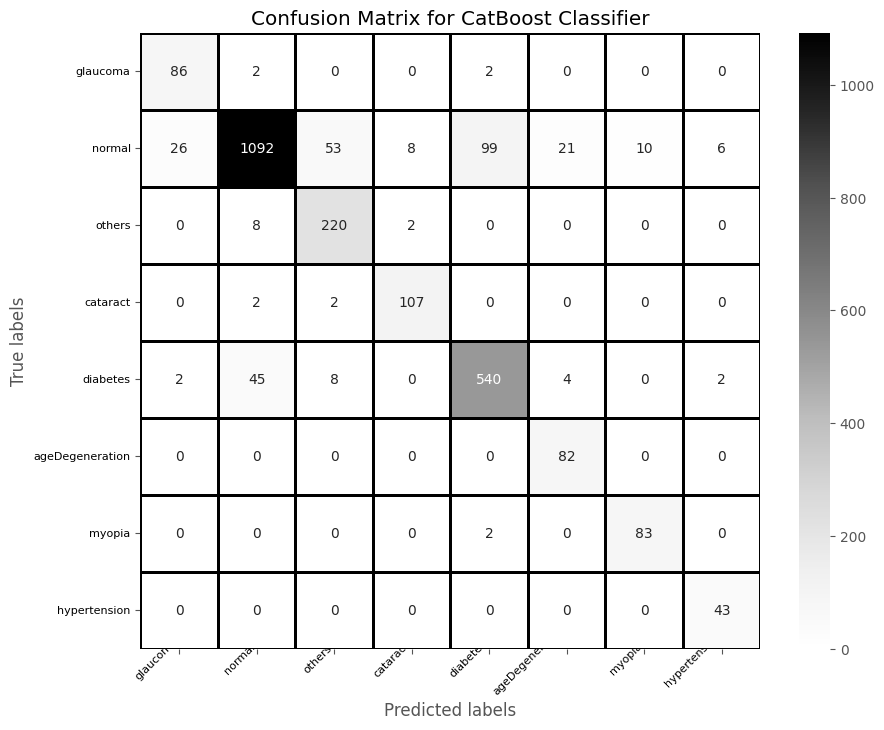

In [ ]:
train_predictions = catboost_model.predict(X_train_pca)

accuracyScore = accuracy_score(y_pred, y_test_processed) * 100
trainaccuracyScore = accuracy_score(train_predictions, y_train_processed)* 100
f1Score = f1_score(y_pred, y_test_processed, average='weighted')
precisionScore = precision_score(y_pred, y_test_processed, average='weighted')
recallScore = recall_score(y_pred, y_test_processed, average='weighted')

print ("Following are the evaluation matrices for CatBoost Classifier Algorithm - \n")

x = PrettyTable(padding_width=5)
x.field_names = [" Name ", "Score"]
x.add_row(['Training Accuracy', str((round(trainaccuracyScore,4)))+'%'])
x.add_row(['Testing Accuracy', str((round(accuracyScore,4)))+'%'])
x.add_row(['F1 Score', str((round(f1Score,4)))] )
x.add_row(['Precision Score', str(round(precisionScore, 4))])
x.add_row(['Recall Score', str(round(recallScore, 4))])
print (x)
print ("\n")
cm = confusion_matrix(y_pred, y_test_processed)

# Use the globally defined class_names_full for consistency and all classes
plt.figure(figsize=(10,8)) # Increased figure size for 8 classes
ax= plt.subplot()
df_cm = pd.DataFrame(cm, index=class_names_full, columns=class_names_full) # Use class_names_full for index and columns
sns.heatmap(df_cm, annot=True, ax = ax, cmap="Greys", fmt='g',linewidth=1,linecolor='black', annot_kws={"size": 10}); #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels');
ax.set_title('Confusion Matrix for CatBoost Classifier');
ax.xaxis.set_ticklabels(class_names_full, rotation=45, ha='right', fontsize="8", va="center", color='black'); # Rotate labels for better readability
ax.yaxis.set_ticklabels(class_names_full, rotation=0, fontsize="8", va="center", color='black');


 Following is the Classification Report for CatBoost Classifier Algorithm - 


[Text(0.5, 0, 'Precision'), Text(1.5, 0, 'Recall'), Text(2.5, 0, 'F1-Score')]

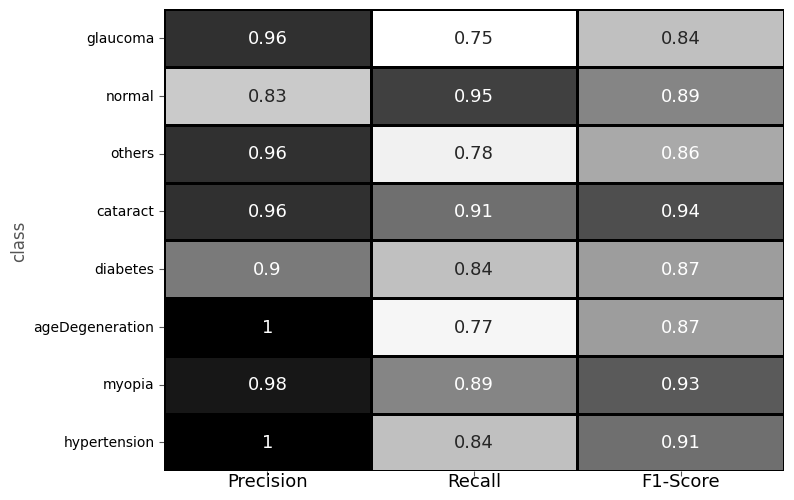

In [ ]:
import sys,re
print ("\n Following is the Classification Report for CatBoost Classifier Algorithm - ")
# Use y_test_processed and y_pred, provide target_names for correct report generation
cf_report = classification_report(y_test_processed, y_pred, target_names=class_names_full)

def classification_report_to_dataframe(cf_report_str, class_names):
    report_data = []
    lines = cf_report_str.split('\n')
    for line in lines[2:-3]: # Skip header and summary lines
        parts = [p for p in line.split(' ') if p]
        # The classification_report output has 5 parts for each class: class_name precision recall f1-score support
        if len(parts) == 5:
            try:
                class_name_from_report = parts[0]
                # Only include rows that correspond to our actual classes, not 'accuracy', 'macro avg', etc.
                if class_name_from_report in class_names:
                    row = {
                        'class': class_name_from_report,
                        'precision': float(parts[1]),
                        'recall': float(parts[2]),
                        'f1_score': float(parts[3])
                    }
                    report_data.append(row)
            except ValueError:
                continue # Skip lines that can't be parsed

    dataframe = pd.DataFrame(report_data)
    if not dataframe.empty:
        dataframe = dataframe.set_index('class')
    return dataframe

# Pass the generated report string and the full class names list
reqDataFrame = classification_report_to_dataframe(cf_report, class_names_full)

plt.figure(figsize=(8,6)) # Adjust figure size
ax= plt.subplot()
sns.heatmap(reqDataFrame, annot=True, ax = ax, cmap="Greys", cbar=False, linewidth=1,linecolor='black', annot_kws={"size": 13}); #annot=True to annotate cells
ax.yaxis.set_ticklabels(reqDataFrame.index, rotation=0, fontsize="10", va="center", color='black') # Use DataFrame index for y-ticks
ax.xaxis.set_ticklabels(['Precision', 'Recall', 'F1-Score'], rotation=0, fontsize="13", va="center", color='black') # Correct order of x-tick labels for clarity

In [ ]:

def print_predictions(y_pred, y_test, class_names=None):
    """
    Print actual vs predicted values for image classification

    Parameters:
    y_pred: predictions
    y_test: actual test labels
    class_names: list of class names (optional)
    """

    # If class names are not provided, use numerical labels
    if class_names is None:
        class_names = [str(i) for i in range(len(np.unique(y_test)))]

    # Create a DataFrame to display results nicely
    results_df = pd.DataFrame({
        'Sr.No.': range(len(y_test)),
        'Actual Label': [class_names[label] for label in y_test],
        'Predicted Label': [class_names[label[0]] for label in y_pred],
        'Correct': [y_test[i] == y_pred[i][0] for i in range(len(y_test))]
    })

    # Limit to first 5 records
    display_df = results_df.head(5)

    # Print the comparison table with simple borders
    print("\nActual vs Predicted Values (First 5 records):")
    print("-" * 60)

    # Create a simple bordered output using string formatting
    header = "| {:^12} | {:^12} | {:^14} | {:^7} |".format(
        "Sr.No.", "Actual Label", "Predicted Label", "Correct"
    )
    print(header)
    print("|" + "-"*14 + "|" + "-"*14 + "|" + "-"*16 + "|" + "-"*9 + "|")

    for index, row in display_df.iterrows():
        print("| {:^12} | {:^12} | {:^14} | {:^7} |".format(
            row['Sr.No.'],
            row['Actual Label'],
            row['Predicted Label'],
            str(row['Correct'])
        ))
    print("-" * 60)


# Use y_test_processed and the globally defined class_names_full
print_predictions(y_pred, y_test_processed, class_names_full)


Actual vs Predicted Values (First 5 records):
------------------------------------------------------------
|    Sr.No.    | Actual Label | Predicted Label | Correct |
|--------------|--------------|----------------|---------|
|      0       |    normal    |     normal     |  True   |
|      1       |   glaucoma   |    diabetes    |  False  |
|      2       |    normal    |     normal     |  True   |
|      3       |    normal    |    diabetes    |  False  |
|      4       |    normal    |     normal     |  True   |
------------------------------------------------------------


In [ ]:
catboost_model.save_model('bestmodel.cbm')
print("Model saved as bestmodel.cbm")

Model saved as bestmodel.cbm
